# PyTorch Continuous XOR Tutorial (Extended)
Extended educational notebook inspired by the UvA Deep Learning course.

Contents:
- Generate continuous XOR data
- Train a neural network
- Visualize learning
- Plot decision boundary

## 1. Imports

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

## 2. Continuous XOR data generator

In [6]:
def generate_xor(n=200):
    X = np.random.uniform(-1,1,(n,2))
    y = (X[:,0]*X[:,1] < 0).astype(np.float32)
    return torch.tensor(X,dtype=torch.float32), torch.tensor(y).unsqueeze(1)

X, y = generate_xor(400)
print(X.shape, y.shape)

torch.Size([400, 2]) torch.Size([400, 1])


## 3. Dataset visualization

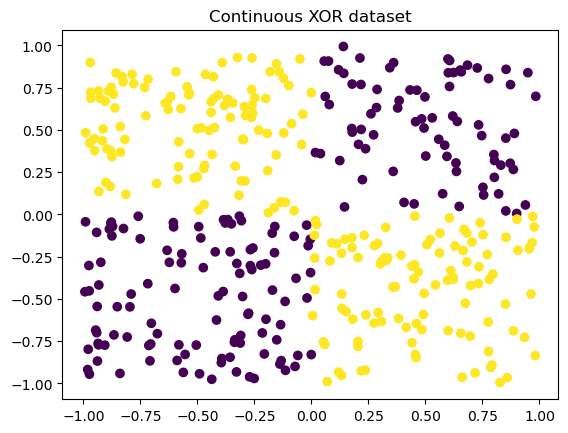

In [9]:
plt.scatter(X[:,0], X[:,1], c=y.squeeze())
plt.title('Continuous XOR dataset')
plt.show()

## 4. Neural network model

In [12]:
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2,8),
            nn.Tanh(),
            nn.Linear(8,8),
            nn.Tanh(),
            nn.Linear(8,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

model = XORNet()

## 5. Training setup

In [15]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

## 6. Training loop

In [18]:
losses = []

for epoch in range(3000):
    pred = model(X)
    loss = criterion(pred,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 500 == 0:
        print(epoch, loss.item())

0 0.713192343711853
500 0.017132973298430443
1000 0.0051311044953763485
1500 0.0019714762456715107
2000 0.0008845466654747725
2500 0.00045454746577888727


## 7. Loss curve

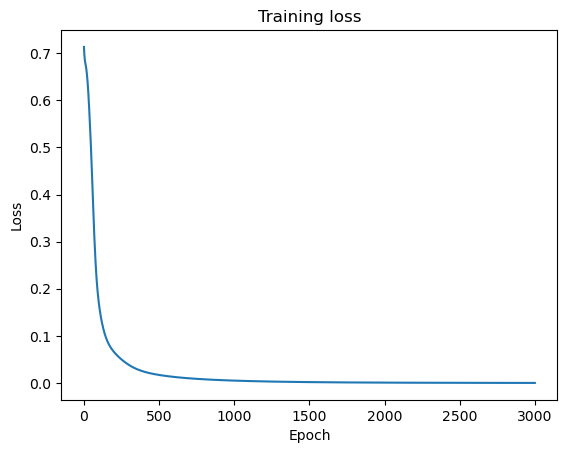

In [21]:
plt.plot(losses)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## 8. Decision boundary visualization

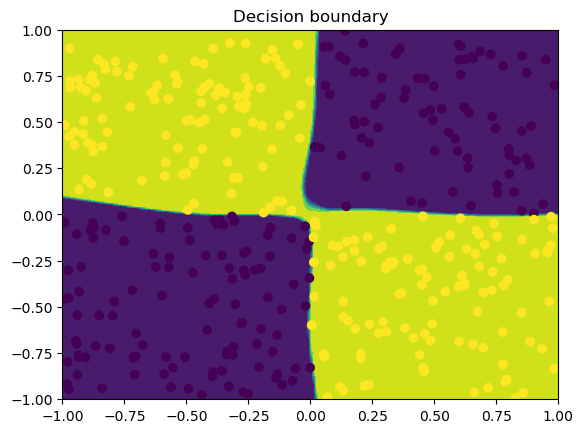

In [24]:
grid_x, grid_y = np.meshgrid(np.linspace(-1,1,200), np.linspace(-1,1,200))
grid = torch.tensor(np.c_[grid_x.ravel(), grid_y.ravel()], dtype=torch.float32)

with torch.no_grad():
    preds = model(grid).reshape(grid_x.shape)

plt.contourf(grid_x, grid_y, preds)
plt.scatter(X[:,0], X[:,1], c=y.squeeze())
plt.title('Decision boundary')
plt.show()